<a href="https://colab.research.google.com/github/hasanulazad-cloud/Project-Title---Data-Visualization/blob/main/Data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python DS Assignment 2-Data Visualization

In [5]:
#1) Loading the Taxis Dataset using the following code:

import seaborn as sns

# Load the 'taxis' dataset
df = sns.load_dataset("taxis")

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset loaded with 6433 rows and 14 columns.



In [10]:
#2) Handling Missing Values

# Check for missing values

print("Initial Missing Values Per Column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("-" * 40)

df.duplicated().sum()



Initial Missing Values Per Column:
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64
----------------------------------------


np.int64(0)

In [9]:
#Impute missing values

# We find the most frequent value (mode) and use it to fill NaN values
payment_mode = df["payment"].mode()[0]
df["payment"] = df["payment"].fillna(payment_mode)
# Remove Rows for Critical Columns
# Define the critical spatial columns where imputation would hurt data integrity
critical_columns = ["pickup_borough","dropoff_borough","pickup_zone","dropoff_zone",]

# Drop rows where any of these critical columns have missing values
df_cleaned = df.dropna(subset=critical_columns)

# Verify that no missing values remain in the entire DataFrame
print("Remaining missing values after cleaning:")
print(df_cleaned.isnull().sum().sum())
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")


Remaining missing values after cleaning:
0
Original dataset shape: (6433, 14)
Cleaned dataset shape: (6383, 14)


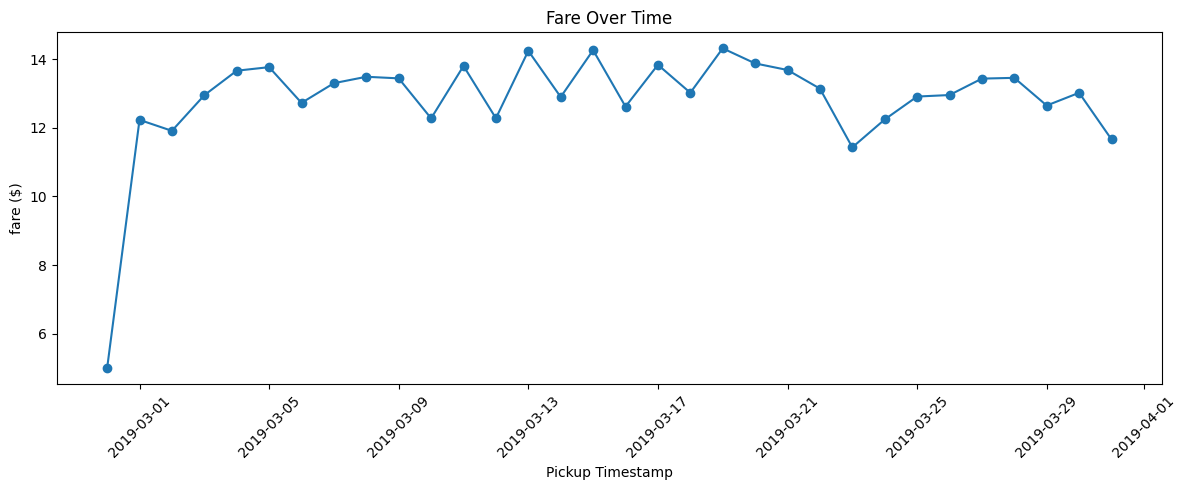

In [18]:
#3) Visualisations using Matplotlib/Pandas Plot:

# Line Chart

#(Plot a line chart to visualise the fare over time, using the pickup timestamp as the x-axis and fare as the y-axis. Ensure the pickup column is converted to a datetime format before plotting.)

import matplotlib.pyplot as plt
import pandas as pd

df["pickup"] = pd.to_datetime(df["pickup"])
df_sorted = df.sort_values(by="pickup")
df_sorted['pickup_date']=df_sorted['pickup'].dt.date
grouped_datefare=df_sorted.groupby('pickup_date')['fare'].mean()

plt.figure(figsize=(12, 5))
plt.plot(grouped_datefare.index,grouped_datefare.values, marker='o')
plt.title("Fare Over Time")
plt.xlabel("Pickup Timestamp")
plt.ylabel("fare ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Total Fare ($)')

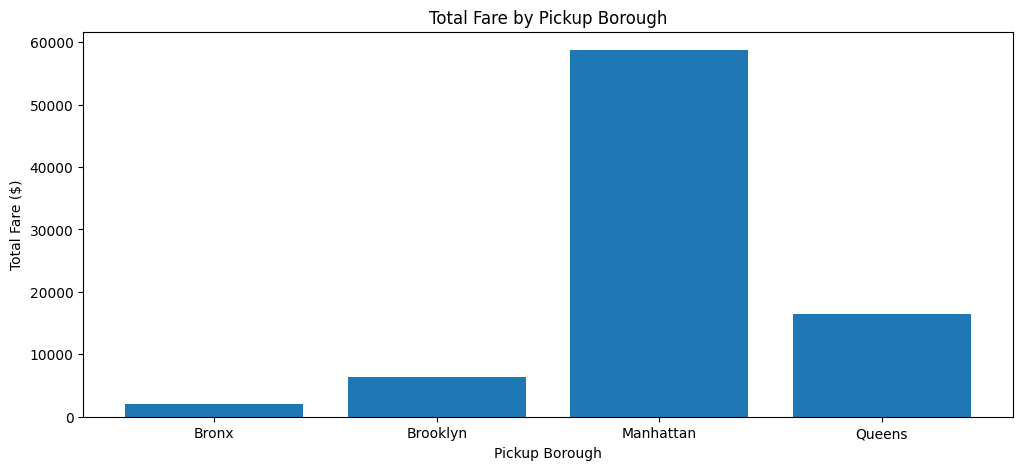

In [19]:
#Bar Chart


#Create a bar chart to show the total fare for each pickup_borough. Group the data by pickup_borough and sum the fare for each group.

grouped_boroughfare=df.groupby('pickup_borough')['fare'].sum()
plt.figure(figsize=(12, 5))
plt.bar(grouped_boroughfare.index,grouped_boroughfare.values)
plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare ($)")


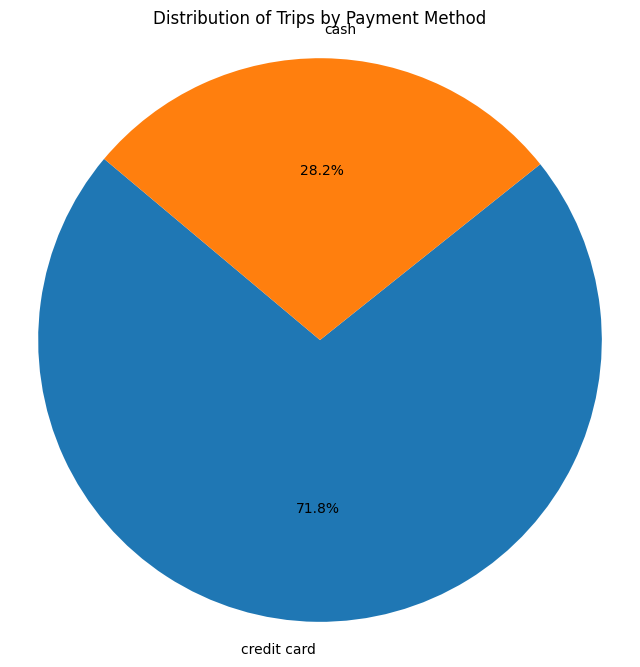

In [20]:
# Pie Chart

#Plot a pie chart showing the distribution of trips based on the payment method (credit card,cash, etc.). Each slice should represent the count of trips for a specific payment method.

payment_counts = df['payment'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Trips by Payment Method')
plt.axis('equal')
plt.show()

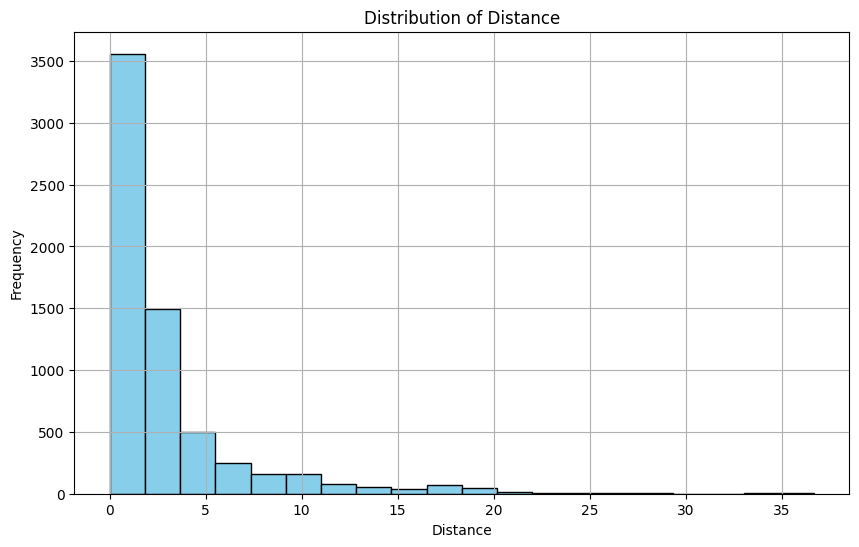

In [21]:
# Histogram

#Create a histogram to visualize the distribution of distance. Customize the number of bins for better granularity and ensure the plot is easy to interpret.

plt.figure(figsize=(10, 6))
plt.hist(df['distance'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Distance')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

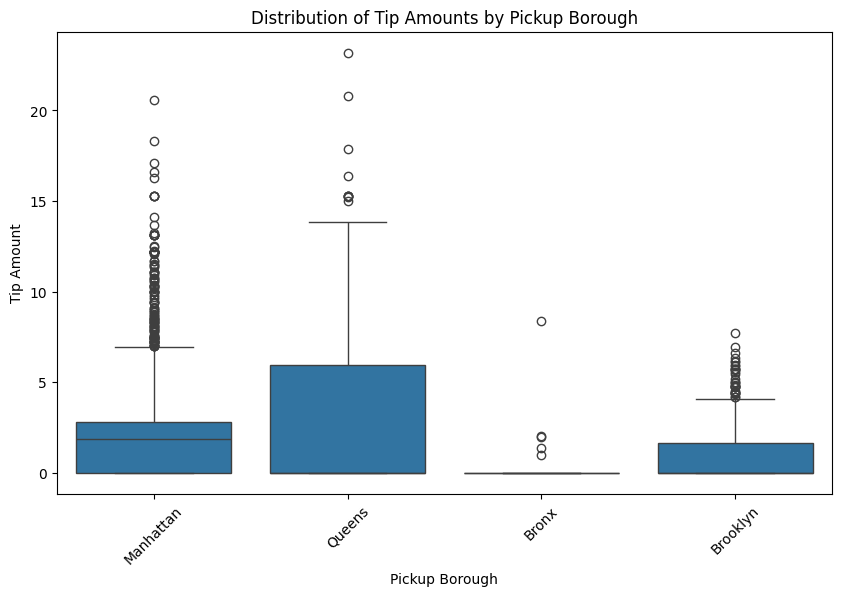

In [22]:
# Box Plot
# Plot a box plot to visualize the distribution of tip amounts for each pickup_borough. Use pickup_borough as the categorical axis and tip as the numeric axis.

plt.figure(figsize=(10, 6))
sns.boxplot(x='pickup_borough', y='tip', data=df)
plt.title('Distribution of Tip Amounts by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.xticks(rotation=45)
plt.show()

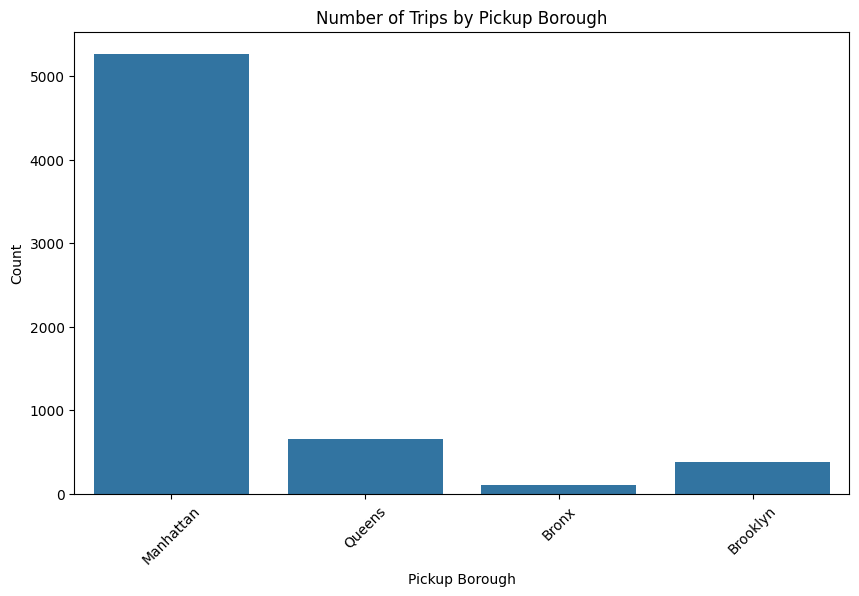

In [23]:
# Count Plot
# Create a count plot to visualize the number of trips in each pickup_borough. The x-axis should represent the boroughs, and the y-axis should show the count of trips.

plt.figure(figsize=(10, 6))
sns.countplot(x='pickup_borough', data=df)
plt.title('Number of Trips by Pickup Borough')
plt.xlabel('Pickup Borough')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

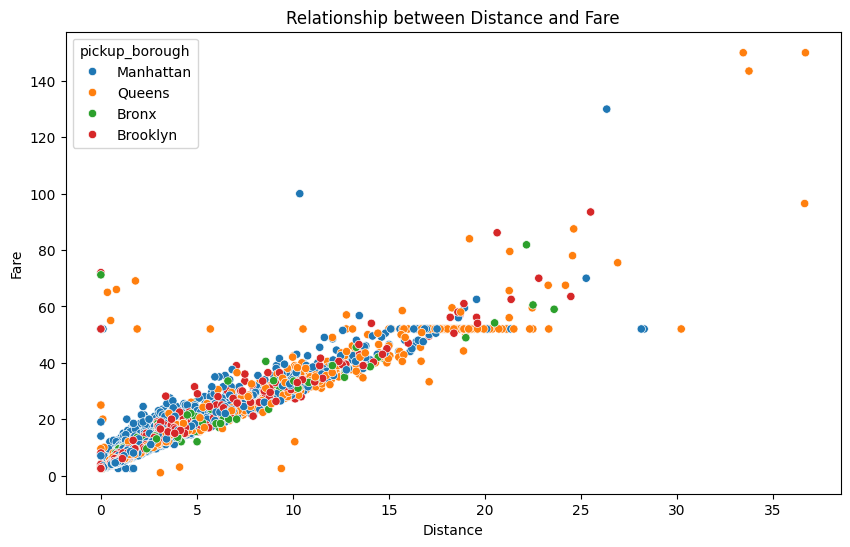

In [24]:
# Scatter Plot
# Plot a scatterplot to show the relationship between distance and fare. Use distance on the x-axis and fare on the y-axis to visualize any correlation. Color the points based on the pickup_borough to differentiate the trips by their respective boroughs.

plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='fare', hue='pickup_borough', data=df)
plt.title('Relationship between Distance and Fare')
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.show()

In [32]:
numeric_df = df.select_dtypes(include=['int64','float64'])
numeric_df=numeric_df.drop('passengers',axis=1)

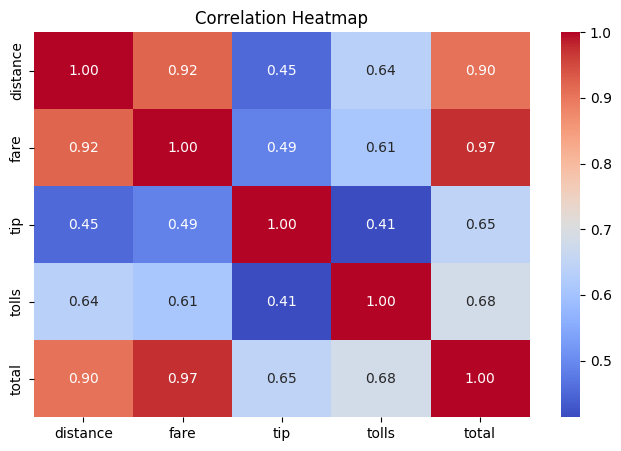

In [34]:
# Heatmap

# Plot a heatmap to visualize the correlation between numerical variables such as distance, fare, tip, tolls, and total. Use a correlation matrix to highlight the relationships.

plt.figure(figsize = (8,5))

sns.heatmap(numeric_df.corr(), annot = True, fmt='.2f',cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

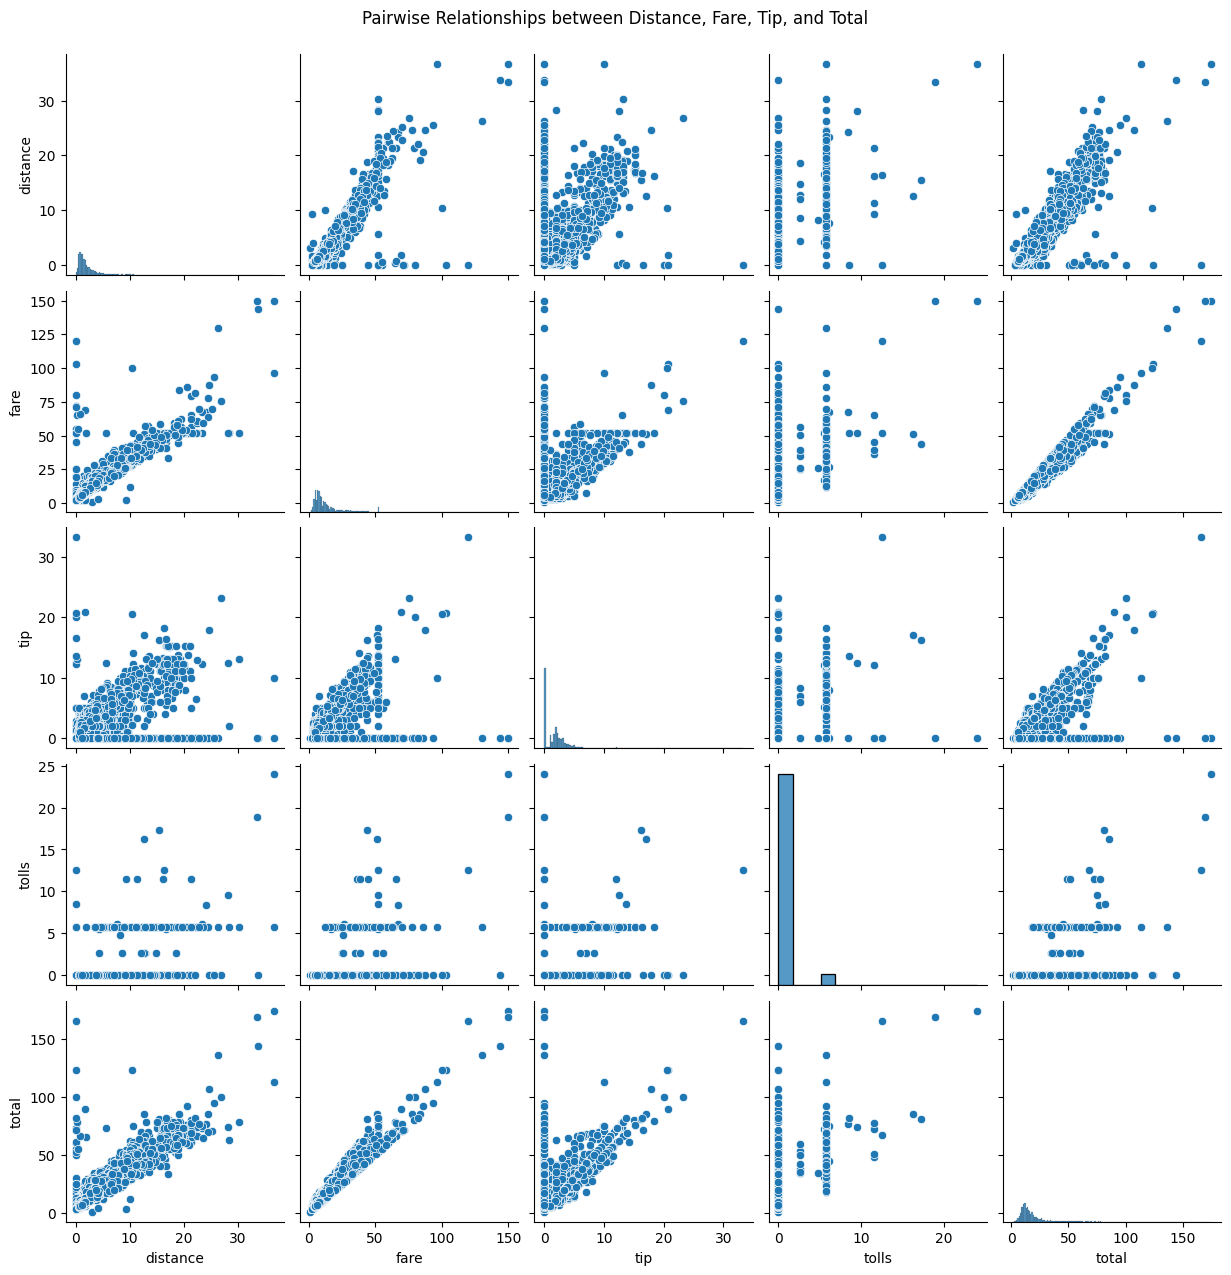

In [35]:
#Pair Plot
#Create a pair plot to visualize the pairwise relationships between distance, fare, tip, and total. Color the data points according to the pickup_zone column. to compare how different zones affect these variables.

sns.pairplot(numeric_df)
plt.suptitle('Pairwise Relationships between Distance, Fare, Tip, and Total', y=1.02)
plt.show()

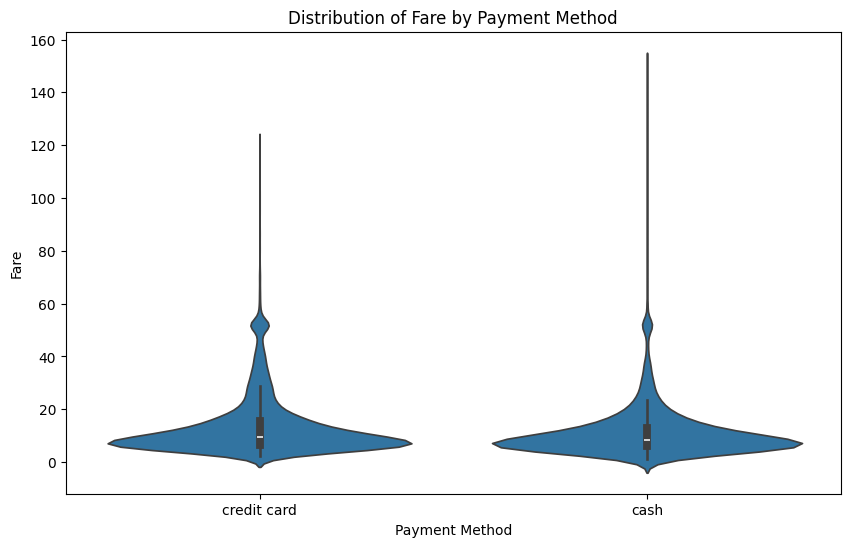

In [36]:
#Violin Plot

#Plot a violin plot to show the distribution of fare for each payment method. Use the payment method as the categorical axis and fare as the numeric axis to visualize its distribution.

plt.figure(figsize=(10, 6))
sns.violinplot(x='payment', y='fare', data=df)
plt.title('Distribution of Fare by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.show()